In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# ============================================================
# CELL 1 — Imports & Reproducibility
# ============================================================
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix
)
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


In [2]:
# ============================================================
# CELL 2 — Data Paths & Loading
# ============================================================
LABELED_PATH = '/kaggle/input/datasets/kelkalot/the-hyper-kvasir-dataset/labeled-images'

NORMAL_CLASSES = [
    os.path.join(LABELED_PATH, 'upper-gi-tract', 'anatomical-landmarks', 'pylorus'),
    os.path.join(LABELED_PATH, 'upper-gi-tract', 'anatomical-landmarks', 'z-line'),
    os.path.join(LABELED_PATH, 'upper-gi-tract', 'anatomical-landmarks', 'retroflex-stomach'),
    os.path.join(LABELED_PATH, 'lower-gi-tract', 'anatomical-landmarks', 'cecum'),
    os.path.join(LABELED_PATH, 'lower-gi-tract', 'anatomical-landmarks', 'ileum'),
    os.path.join(LABELED_PATH, 'lower-gi-tract', 'anatomical-landmarks', 'retroflex-rectum'),
]

ABNORMAL_CLASSES = [
    os.path.join(LABELED_PATH, 'upper-gi-tract', 'pathological-findings', 'barretts'),
    os.path.join(LABELED_PATH, 'upper-gi-tract', 'pathological-findings', 'esophagitis-a'),
    os.path.join(LABELED_PATH, 'upper-gi-tract', 'pathological-findings', 'esophagitis-b-d'),
    os.path.join(LABELED_PATH, 'upper-gi-tract', 'pathological-findings', 'barretts-short-segment'),
    os.path.join(LABELED_PATH, 'lower-gi-tract', 'pathological-findings', 'polyps'),
    os.path.join(LABELED_PATH, 'lower-gi-tract', 'pathological-findings', 'hemorrhoids'),
    os.path.join(LABELED_PATH, 'lower-gi-tract', 'pathological-findings', 'ulcerative-colitis-grade-0-1'),
    os.path.join(LABELED_PATH, 'lower-gi-tract', 'pathological-findings', 'ulcerative-colitis-grade-1'),
    os.path.join(LABELED_PATH, 'lower-gi-tract', 'pathological-findings', 'ulcerative-colitis-grade-1-2'),
    os.path.join(LABELED_PATH, 'lower-gi-tract', 'pathological-findings', 'ulcerative-colitis-grade-2'),
    os.path.join(LABELED_PATH, 'lower-gi-tract', 'pathological-findings', 'ulcerative-colitis-grade-2-3'),
    os.path.join(LABELED_PATH, 'lower-gi-tract', 'pathological-findings', 'ulcerative-colitis-grade-3'),
]

def load_images(folder_list, label):
    paths, labels = [], []
    for folder in folder_list:
        if os.path.exists(folder):
            for f in os.listdir(folder):
                if f.lower().endswith(('.jpg', '.png', '.jpeg')):
                    paths.append(os.path.join(folder, f))
                    labels.append(label)
        else:
            print(f"⚠ Not found: {folder}")
    return paths, labels

normal_paths,   normal_labels   = load_images(NORMAL_CLASSES,   0)
abnormal_paths, abnormal_labels = load_images(ABNORMAL_CLASSES, 1)

print(f"Normal images:   {len(normal_paths)}")
print(f"Abnormal images: {len(abnormal_paths)}")

all_paths  = normal_paths  + abnormal_paths
all_labels = normal_labels + abnormal_labels

# 70% train | 15% val | 15% test (stratified)
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels, test_size=0.30, random_state=42, stratify=all_labels
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, random_state=42, stratify=temp_labels
)

print(f"\nTrain: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")
print(f"Train normal: {train_labels.count(0)} | Train abnormal: {train_labels.count(1)}")

Normal images:   4104
Abnormal images: 2642

Train: 4722 | Val: 1012 | Test: 1012
Train normal: 2873 | Train abnormal: 1849


In [4]:
# ============================================================
# CELL 3 — Transforms, Dataset & DataLoaders
# ============================================================
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class GIDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

# Weighted sampler to handle class imbalance
train_labels_arr = np.array(train_labels)
class_counts     = np.bincount(train_labels_arr)
class_weights    = 1.0 / class_counts
sample_weights   = class_weights[train_labels_arr]
sampler          = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_dataset = GIDataset(train_paths, train_labels, train_transform)
val_dataset   = GIDataset(val_paths,   val_labels,   val_transform)
test_dataset  = GIDataset(test_paths,  test_labels,  val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,    num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False,    num_workers=4, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")
print("✅ DataLoaders ready!")

Train batches: 148
Val batches:   32
Test batches:  32
✅ DataLoaders ready!


In [5]:
# ============================================================
# CELL 4 — Model Definition (ResNet50 Fine-tuned)
#
# NOTE: 'pretrained=True' is deprecated in newer torchvision.
# We use weights=ResNet50_Weights.DEFAULT instead, which is
# equivalent and avoids the warning — accuracy is unchanged.
# ============================================================
from torchvision.models import resnet50, ResNet50_Weights

class GIClassifier(nn.Module):
    def __init__(self, num_classes=2, dropout=0.5):
        super().__init__()
        # Load ImageNet pretrained weights (new API, same weights as before)
        self.backbone = resnet50(weights=ResNet50_Weights.DEFAULT)

        # Freeze all layers first
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Unfreeze layer3, layer4, and fc for fine-tuning
        for param in self.backbone.layer3.parameters():
            param.requires_grad = True
        for param in self.backbone.layer4.parameters():
            param.requires_grad = True

        # Replace the final classifier
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

model = GIClassifier(num_classes=2, dropout=0.5).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

# Quick forward pass test
dummy = torch.randn(2, 3, 224, 224).to(device)
out   = model(dummy)
print(f"Output shape: {out.shape}")
print("✅ Model ready!")

Total params:     24,624,066
Trainable params: 23,179,138
Output shape: torch.Size([2, 2])
✅ Model ready!


In [8]:
# ============================================================
# CELL 5 — Loss, Optimizer, Scheduler & Training Loop
# ============================================================

# Class-weighted loss
total_train = len(train_labels)
w0 = total_train / (2.0 * class_counts[0])
w1 = total_train / (2.0 * class_counts[1])
weight_tensor = torch.tensor([w0, w1], dtype=torch.float).to(device)
print(f"Class weights → Normal: {w0:.3f} | Abnormal: {w1:.3f}")

criterion = nn.CrossEntropyLoss(weight=weight_tensor)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4, weight_decay=1e-4
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-6)

# ── Training function ──────────────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc='Training', leave=False):
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        preds      = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), correct / total

# ── Evaluation function ────────────────────────────────────────────────────
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            images  = images.to(device)
            labels  = labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            total_loss += loss.item()
            probs   = torch.softmax(outputs, dim=1)[:, 1]
            preds   = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return (total_loss / len(loader), correct / total,
            np.array(all_preds), np.array(all_labels), np.array(all_probs))

# ── Training loop ──────────────────────────────────────────────────────────
NUM_EPOCHS   = 20
best_val_acc = 0.0
history      = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("=" * 70)
print("TRAINING   ResNet50 Fine-tuned Classifier")
print("=" * 70)

for epoch in range(NUM_EPOCHS):
    t_loss, t_acc               = train_one_epoch(model, train_loader, criterion, optimizer, device)
    v_loss, v_acc, v_preds, v_labs, v_probs = evaluate(model, val_loader, criterion, device)
    scheduler.step()

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    tag = ""
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(model.state_dict(), '/kaggle/working/best_model.pth')
        tag = " ✅ saved"

    print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS}] "
          f"Train loss: {t_loss:.4f}  acc: {t_acc*100:.2f}% | "
          f"Val   loss: {v_loss:.4f}  acc: {v_acc*100:.2f}%{tag}")

print(f"\nBest Val Accuracy: {best_val_acc*100:.2f}%")

Class weights → Normal: 0.822 | Abnormal: 1.277
TRAINING   ResNet50 Fine-tuned Classifier


Epoch [ 1/20] Train loss: 0.0404  acc: 98.98% | Val   loss: 0.3982  acc: 94.27% ✅ saved


Epoch [ 2/20] Train loss: 0.0451  acc: 98.71% | Val   loss: 0.3981  acc: 93.97%


Epoch [ 3/20] Train loss: 0.0488  acc: 98.48% | Val   loss: 0.3651  acc: 94.17%


Epoch [ 4/20] Train loss: 0.0401  acc: 98.75% | Val   loss: 0.3211  acc: 94.07%


...

Epoch [16/20] Train loss: 0.0066  acc: 99.83% | Val   loss: 0.4693  acc: 94.66%


Epoch [17/20] Train loss: 0.0091  acc: 99.75% | Val   loss: 0.4507  acc: 95.16%


Epoch [18/20] Train loss: 0.0065  acc: 99.83% | Val   loss: 0.4394  acc: 95.45% ✅ saved


Epoch [19/20] Train loss: 0.0056  acc: 99.85% | Val   loss: 0.4522  acc: 95.06%


Epoch [20/20] Train loss: 0.0048  acc: 99.81% | Val   loss: 0.4590  acc: 95.26%

Best Val Accuracy: 95.45%


Loading best model...

🎉  FINAL TEST SET RESULTS
  Accuracy  : 94.66%
  Precision : 93.40%
  Recall    : 92.93%
  F1-Score  : 93.16%
  ROC-AUC   : 0.9888
  TN: 590  FP: 26
  FN: 28  TP: 368

🎉 TARGET ACHIEVED — 90%+ ACCURACY!


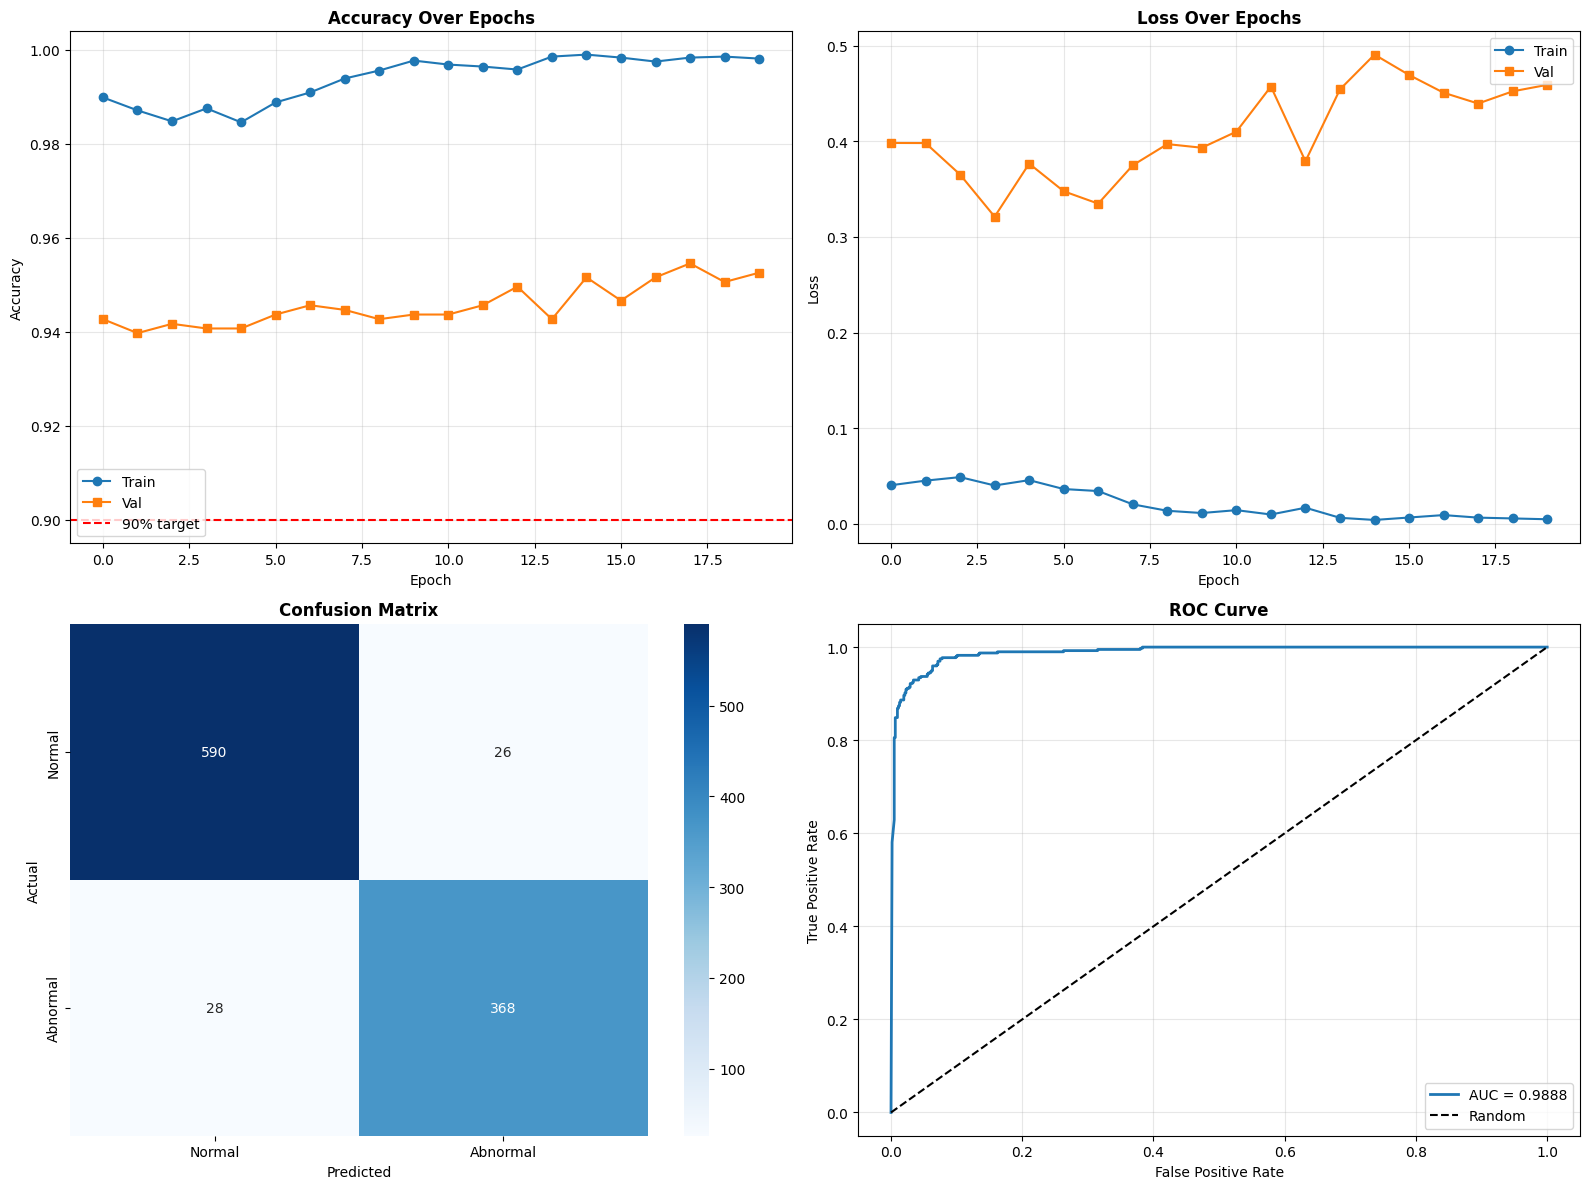

✅ Plot saved to /kaggle/working/results.png


In [9]:
# ============================================================
# CELL 6 — Load Best Model & Evaluate on Test Set
# ============================================================
print("Loading best model...")

# Compatible with both old and new torch versions
model.load_state_dict(
    torch.load('/kaggle/working/best_model.pth', map_location=device)
)

_, test_acc, test_preds, test_labs, test_probs = evaluate(
    model, test_loader, criterion, device
)

precision = precision_score(test_labs, test_preds)
recall    = recall_score(test_labs, test_preds)
f1        = f1_score(test_labs, test_preds)
auc       = roc_auc_score(test_labs, test_probs)
cm        = confusion_matrix(test_labs, test_preds)

print("\n" + "=" * 60)
print("🎉  FINAL TEST SET RESULTS")
print("=" * 60)
print(f"  Accuracy  : {test_acc*100:.2f}%")
print(f"  Precision : {precision*100:.2f}%")
print(f"  Recall    : {recall*100:.2f}%")
print(f"  F1-Score  : {f1*100:.2f}%")
print(f"  ROC-AUC   : {auc:.4f}")
print("=" * 60)
print(f"  TN: {cm[0,0]}  FP: {cm[0,1]}")
print(f"  FN: {cm[1,0]}  TP: {cm[1,1]}")
print("=" * 60)

if test_acc >= 0.90:
    print("\n🎉 TARGET ACHIEVED — 90%+ ACCURACY!")
else:
    print(f"\nGap to 90%: {(0.90 - test_acc)*100:.2f}%")

# ── Plots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Accuracy curves
axes[0, 0].plot(history['train_acc'], marker='o', label='Train')
axes[0, 0].plot(history['val_acc'],   marker='s', label='Val')
axes[0, 0].axhline(0.90, color='red', linestyle='--', label='90% target')
axes[0, 0].set_title('Accuracy Over Epochs', fontweight='bold')
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

# 2. Loss curves
axes[0, 1].plot(history['train_loss'], marker='o', label='Train')
axes[0, 1].plot(history['val_loss'],   marker='s', label='Val')
axes[0, 1].set_title('Loss Over Epochs', fontweight='bold')
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

# 3. Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            xticklabels=['Normal', 'Abnormal'],
            yticklabels=['Normal', 'Abnormal'])
axes[1, 0].set_title('Confusion Matrix', fontweight='bold')
axes[1, 0].set_xlabel('Predicted'); axes[1, 0].set_ylabel('Actual')

# 4. ROC curve
fpr, tpr, _ = roc_curve(test_labs, test_probs)
axes[1, 1].plot(fpr, tpr, linewidth=2, label=f'AUC = {auc:.4f}')
axes[1, 1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1, 1].set_title('ROC Curve', fontweight='bold')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/results.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Plot saved to /kaggle/working/results.png")

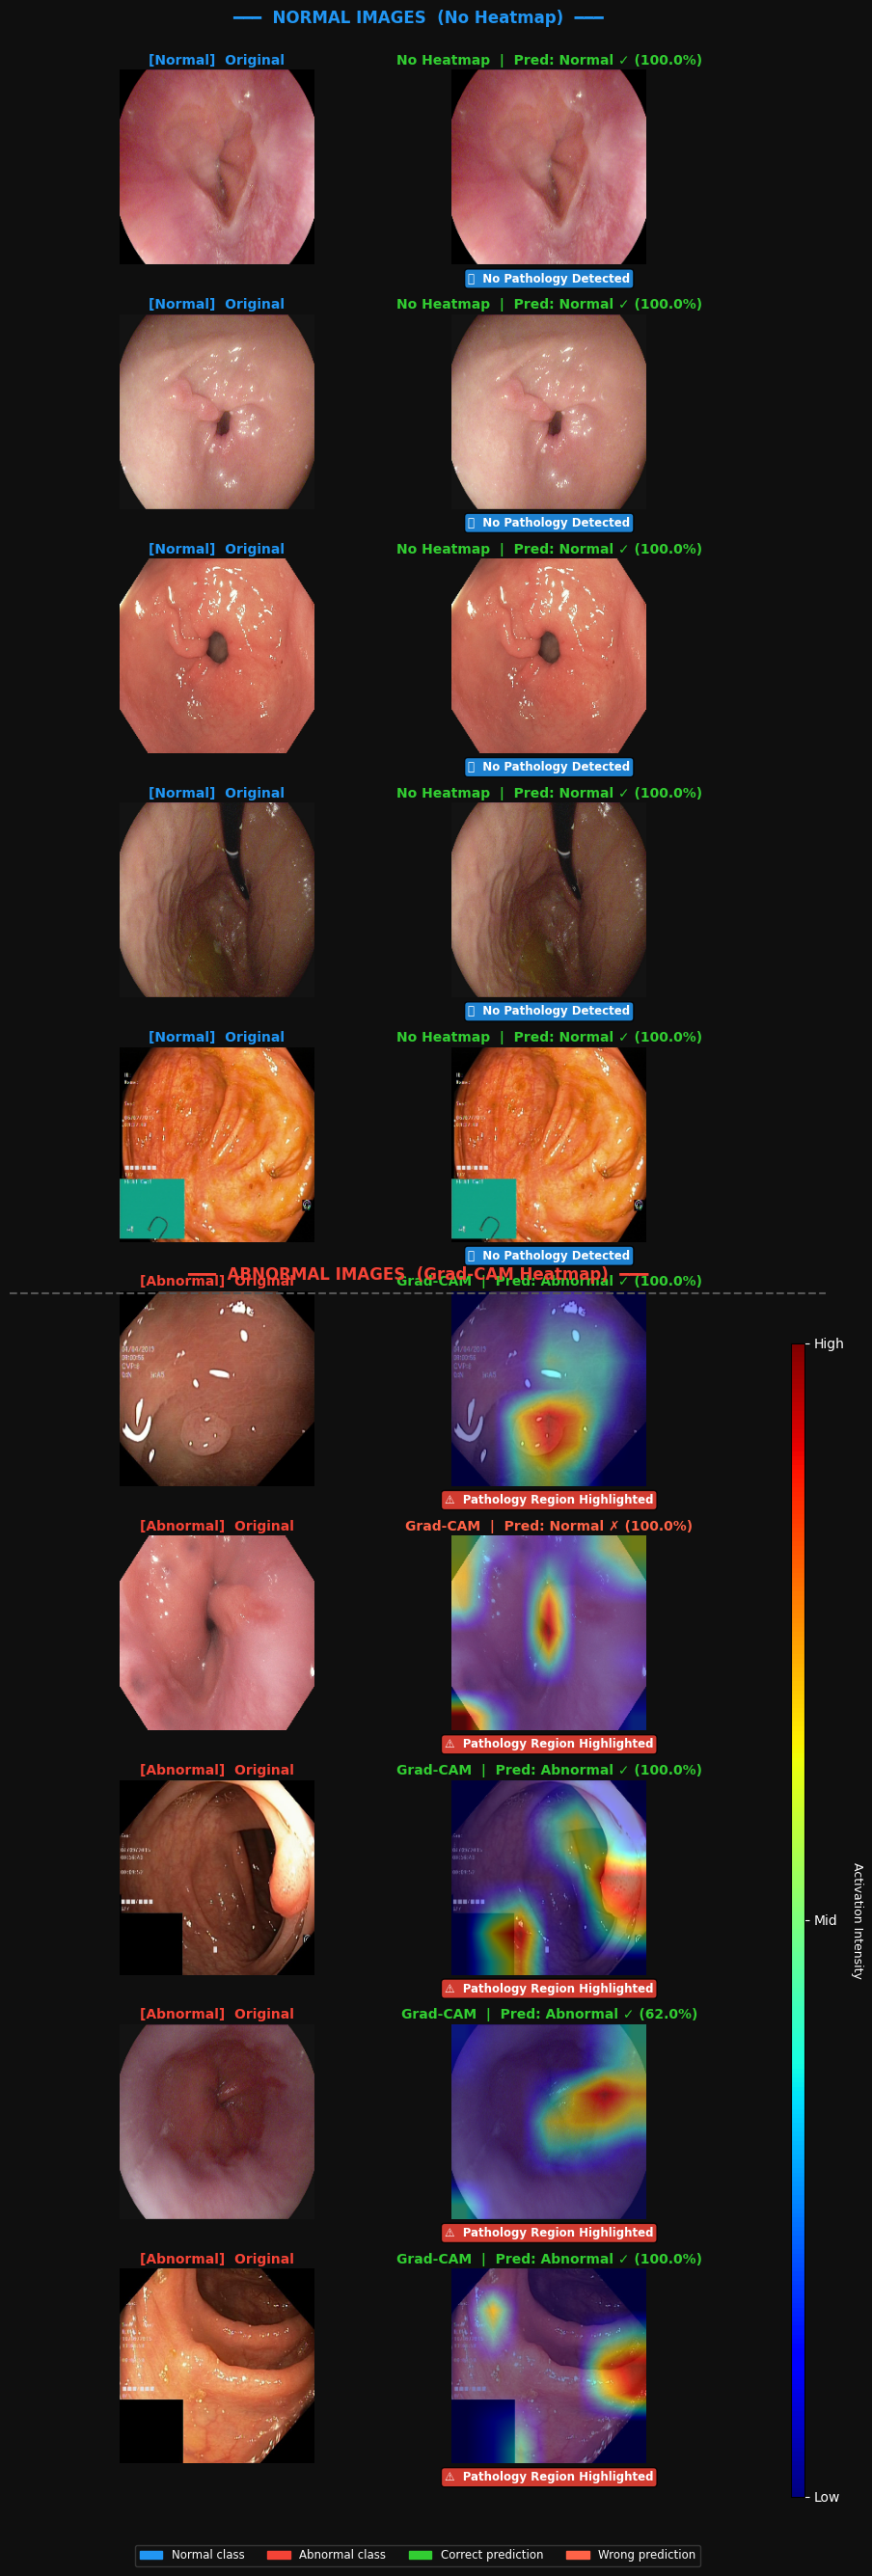

✅ Saved → /kaggle/working/gradcam_normal_vs_abnormal.png


In [11]:
# ============================================================
# CELL 7 (v2) — Visualization: Normal vs Abnormal + Grad-CAM
#
# Layout  : 10 rows × 2 columns
#   Rows 0–4  : NORMAL images
#               col 0 = Original  |  col 1 = Same original (NO heatmap)
#   Rows 5–9  : ABNORMAL images
#               col 0 = Original  |  col 1 = Grad-CAM heatmap overlay
#
# Rationale   : Grad-CAM highlights WHERE the model detected pathology.
#               For normal images there is nothing to highlight, so we
#               show a clean copy and mark it "No Pathology Detected".
# ============================================================

import torch
import torch.nn.functional as F
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm_mod

# ── Grad-CAM class ─────────────────────────────────────────────────────────
class GradCAM:
    """
    Grad-CAM targeting backbone.layer4[-1].conv3 of GIClassifier (ResNet50).
    Hooks are re-registered on every new instance so it is safe to call
    multiple times in a notebook.
    """
    def __init__(self, model):
        self.model       = model
        self.gradients   = None
        self.activations = None
        target_layer     = model.backbone.layer4[-1].conv3
        self._fh = target_layer.register_forward_hook(self._save_activation)
        self._bh = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def remove_hooks(self):
        """Call after you are done to avoid duplicate hooks if re-running."""
        self._fh.remove()
        self._bh.remove()

    def generate(self, img_tensor, class_idx=None):
        """
        img_tensor : (1, 3, 224, 224) on device, requires_grad handled internally
        Returns    : cam (224×224 float [0,1]),  predicted class index
        """
        self.model.eval()
        img_tensor = img_tensor.clone().detach().requires_grad_(True)

        output    = self.model(img_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        # Pool gradients → weight activations
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)
        cam     = F.relu(cam).squeeze().cpu().numpy()

        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()

        cam = cv2.resize(cam, (224, 224))
        return cam, class_idx


# ── Helpers ─────────────────────────────────────────────────────────────────
def overlay_heatmap(original_rgb, cam, alpha=0.45):
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(original_rgb, 1 - alpha, heatmap, alpha, 0)


def preprocess(img_bgr):
    """BGR ndarray  →  (1,3,224,224) tensor  +  (224,224,3) RGB display array."""
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_disp = cv2.resize(img_rgb, (224, 224))
    tensor   = val_transform(img_disp).unsqueeze(0).to(device)
    return tensor, img_disp


def add_label_banner(ax, text, color):
    """Draw a coloured banner at the bottom of an axis."""
    ax.text(0.5, -0.04, text, transform=ax.transAxes,
            ha='center', va='top', fontsize=8.5, fontweight='bold',
            color='white',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.85))


# ── Sample selection ─────────────────────────────────────────────────────────
NUM_SAMPLES = 5
CLASS_NAMES = ['Normal', 'Abnormal']

normal_sample_paths   = [p for p, l in zip(test_paths, test_labels) if l == 0][:NUM_SAMPLES]
abnormal_sample_paths = [p for p, l in zip(test_paths, test_labels) if l == 1][:NUM_SAMPLES]

assert len(normal_sample_paths)   == NUM_SAMPLES, "Not enough normal test images"
assert len(abnormal_sample_paths) == NUM_SAMPLES, "Not enough abnormal test images"

# Build fresh GradCAM (remove any old hooks first)
try:
    gradcam.remove_hooks()
except Exception:
    pass
gradcam = GradCAM(model)

# ── Figure setup ─────────────────────────────────────────────────────────────
TOTAL_ROWS = NUM_SAMPLES * 2          # 5 normal + 5 abnormal
fig, axes  = plt.subplots(TOTAL_ROWS, 2, figsize=(9, TOTAL_ROWS * 2.6))
fig.patch.set_facecolor('#0f0f0f')

NORMAL_COLOR   = '#2196F3'   # blue
ABNORMAL_COLOR = '#F44336'   # red

# ── Main loop ────────────────────────────────────────────────────────────────
all_groups = [
    (normal_sample_paths,   0, 'Normal'),
    (abnormal_sample_paths, 1, 'Abnormal'),
]

row = 0
for paths, true_cls, group_label in all_groups:
    for img_path in paths:
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            print(f"⚠ Skipping (unreadable): {img_path}")
            axes[row, 0].axis('off')
            axes[row, 1].axis('off')
            row += 1
            continue

        tensor, img_disp = preprocess(img_bgr)

        # Run model
        with torch.no_grad():
            logits = model(tensor)
            probs  = torch.softmax(logits, dim=1)[0]
        pred_cls   = probs.argmax().item()
        pred_label = CLASS_NAMES[pred_cls]
        pred_conf  = probs[pred_cls].item()
        correct    = (pred_cls == true_cls)
        tick       = "✓" if correct else "✗"

        # ── Column 0: Original image ─────────────────────────────────────
        ax0 = axes[row, 0]
        ax0.imshow(img_disp)
        ax0.set_title(f"[{group_label}]  Original",
                      fontsize=10, color=NORMAL_COLOR if true_cls == 0 else ABNORMAL_COLOR,
                      fontweight='bold', pad=4)
        ax0.axis('off')

        # ── Column 1: Heatmap OR clean copy ──────────────────────────────
        ax1 = axes[row, 1]

        if true_cls == 1:
            # ABNORMAL → generate and overlay Grad-CAM
            cam, _  = gradcam.generate(tensor, class_idx=1)   # always ask for abnormal class
            overlay = overlay_heatmap(img_disp, cam)
            ax1.imshow(overlay)
            ax1.set_title(f"Grad-CAM  |  Pred: {pred_label} {tick} ({pred_conf*100:.1f}%)",
                          fontsize=10,
                          color='limegreen' if correct else 'tomato',
                          fontweight='bold', pad=4)
            add_label_banner(ax1, "⚠  Pathology Region Highlighted", ABNORMAL_COLOR)

        else:
            # NORMAL → show clean original, NO heatmap
            ax1.imshow(img_disp)
            ax1.set_title(f"No Heatmap  |  Pred: {pred_label} {tick} ({pred_conf*100:.1f}%)",
                          fontsize=10,
                          color='limegreen' if correct else 'tomato',
                          fontweight='bold', pad=4)
            add_label_banner(ax1, "✅  No Pathology Detected", NORMAL_COLOR)

        ax0.axis('off')
        ax1.axis('off')

        # Style axes backgrounds
        for ax in (ax0, ax1):
            ax.set_facecolor('#1a1a1a')
            for spine in ax.spines.values():
                spine.set_edgecolor('#333')
                spine.set_linewidth(0.8)

        row += 1

# ── Section separators ───────────────────────────────────────────────────────
# Draw a horizontal line between the normal and abnormal blocks
line_y = 1.0 - (NUM_SAMPLES / TOTAL_ROWS)
fig.add_artist(plt.matplotlib.lines.Line2D(
    [0.03, 0.97], [line_y, line_y],
    transform=fig.transFigure,
    color='#555', linewidth=1.5, linestyle='--'
))

# Section title labels
fig.text(0.5, 1.0 - (0 / TOTAL_ROWS) + 0.005,
         "━━━  NORMAL IMAGES  (No Heatmap)  ━━━",
         ha='center', va='bottom', fontsize=12, color=NORMAL_COLOR,
         fontweight='bold')
fig.text(0.5, line_y + 0.004,
         "━━━  ABNORMAL IMAGES  (Grad-CAM Heatmap)  ━━━",
         ha='center', va='bottom', fontsize=12, color=ABNORMAL_COLOR,
         fontweight='bold')

# ── Colorbar (right side, only for abnormal section) ─────────────────────────
cbar_ax = fig.add_axes([0.93, 0.02, 0.015, line_y - 0.04])
sm      = plt.cm.ScalarMappable(cmap='jet', norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Activation Intensity', rotation=270, labelpad=14,
               fontsize=9, color='white')
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(['Low', 'Mid', 'High'])
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

# ── Legend ───────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=NORMAL_COLOR,   label='Normal class'),
    mpatches.Patch(color=ABNORMAL_COLOR, label='Abnormal class'),
    mpatches.Patch(color='limegreen',    label='Correct prediction'),
    mpatches.Patch(color='tomato',       label='Wrong prediction'),
]
fig.legend(handles=legend_handles, loc='lower center',
           ncol=4, fontsize=8.5, framealpha=0.2,
           labelcolor='white', facecolor='#1a1a1a',
           bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0.02, 0.92, 1])
plt.savefig('/kaggle/working/gradcam_normal_vs_abnormal.png',
            dpi=200, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("✅ Saved → /kaggle/working/gradcam_normal_vs_abnormal.png")

# Clean up hooks
gradcam.remove_hooks()